# Issue #3 — EDA: Análise Exploratória dos Dados
Carregamos os dados do banco `sompo.db` e exploramos distribuições, correlações e outliers.

In [10]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estilo dos gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13

## 1. Carregar dados do banco

In [11]:
# Ajuste o caminho conforme onde está o sompo.db no seu projeto
DB_PATH = '../../sompo.db'

conn = sqlite3.connect(DB_PATH)

# Lista as tabelas disponíveis
tabelas = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print('Tabelas no banco:')
print(tabelas)

Tabelas no banco:
              name
0     equipamentos
1       telemetria
2    scores_modelo
3  sqlite_sequence
4          alertas
5         usuarios
6     regras_risco


In [12]:
# Carrega a tabela principal (ajuste o nome se necessário)
df = pd.read_sql('SELECT * FROM telemetria', conn)
conn.close()

print(f'Shape: {df.shape}')
df.head()

Shape: (1000, 35)


,id_registro,id_equipamento,data_hora,latitude,longitude,tipo_operacao,proximidade_agua_m,precipitacao_mm,umidade_solo_pct,tipo_solo,...,faixa_proximidade_agua,faixa_proximidade_encoded,indice_desgaste,risco_solo,risco_atolamento,risco_operacional,risco_manutencao,score_risco_calculado,diff_score,data_ingestao
0,1,EQ-GO-0006,2024-06-19 23:00:00,-16.313186,-49.764875,Campo,2316,14.1,24.2,Arenoso,...,Baixo,0,53.407080,0.000000,11.995,37.01,107.841667,56,0.0,2026-06-02 03:19:29
1,2,EQ-PR-0025,2024-05-21 19:00:00,-24.193304,-51.165445,Campo,940,4.9,37.3,Misto,...,Baixo,0,61.750000,3.485981,22.280,66.13,22.833333,36,0.0,2026-06-02 03:19:29
2,3,EQ-GO-0007,2024-06-01 01:00:00,-16.336425,-49.616073,Campo,30,4.6,47.3,Argiloso,...,Crítico,3,172.187500,15.015873,108.705,73.53,37.558333,80,0.0,2026-06-02 03:19:29
3,4,EQ-PR-0023,2024-06-06 15:00:00,-24.214566,-52.179199,Campo,1924,4.5,49.8,Argiloso,...,Baixo,0,61.870968,62.250000,34.555,47.18,89.500000,41,0.0,2026-06-02 03:19:29
4,5,EQ-PR-0023,2024-01-10 15:00:00,-24.217984,-52.179268,Campo,179,2.9,20.8,Arenoso,...,Alto,2,64.500000,0.000000,58.005,59.87,7.100000,57,0.0,2026-06-02 03:19:29


## 2. Visão geral do dataset

In [13]:
print('=== Tipos e nulos ===')
print(df.dtypes)
print(f'\nValores nulos por coluna:')
print(df.isnull().sum())

=== Tipos e nulos ===
id_registro                    int64
id_equipamento                   str
data_hora                        str
latitude                     float64
longitude                    float64
tipo_operacao                    str
proximidade_agua_m             int64
precipitacao_mm              float64
umidade_solo_pct             float64
tipo_solo                        str
declividade_graus            float64
temperatura_c                float64
velocidade_vento_kmh         float64
visibilidade_m                 int64
horas_uso_equipamento          int64
dias_ultima_manutencao         int64
velocidade_operacao_kmh      float64
carga_pct                    float64
nivel_combustivel_pct        float64
historico_incidentes           int64
score_risco                    int64
nivel_risco                      str
alerta_gerado                  int64
tipo_solo_encoded              int64
tipo_operacao_encoded          int64
faixa_proximidade_agua           str
faixa_proximidad

In [14]:
print('=== Estatísticas descritivas ===')
df.describe().round(2)

=== Estatísticas descritivas ===


,id_registro,latitude,longitude,proximidade_agua_m,precipitacao_mm,umidade_solo_pct,declividade_graus,temperatura_c,velocidade_vento_kmh,visibilidade_m,...,tipo_solo_encoded,tipo_operacao_encoded,faixa_proximidade_encoded,indice_desgaste,risco_solo,risco_atolamento,risco_operacional,risco_manutencao,score_risco_calculado,diff_score
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,...,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.0
mean,500.50,-18.89,-50.98,2538.40,14.68,40.70,5.51,29.46,30.14,4166.01,...,1.07,0.72,0.86,170.11,48.04,48.07,55.69,68.48,49.00,0.0
std,288.82,5.63,3.41,3226.81,21.25,19.14,4.80,5.52,14.42,1142.57,...,0.88,0.45,1.08,360.86,166.01,31.45,14.20,28.35,29.38,0.0
min,1.00,-29.81,-56.73,5.00,0.00,9.80,0.00,18.10,5.00,150.00,...,0.00,0.00,0.00,4.83,0.00,3.58,19.63,6.35,0.00,0.0
25%,250.75,-23.27,-53.47,167.75,2.00,25.10,1.90,25.30,18.18,3870.75,...,0.00,0.00,0.00,38.83,0.00,22.98,46.13,47.63,24.00,0.0
50%,500.50,-16.43,-50.49,726.50,4.30,38.35,3.95,29.50,30.35,4640.50,...,1.00,1.00,0.00,69.59,8.07,37.49,55.20,67.92,48.00,0.0
75%,750.25,-13.66,-48.98,5562.50,20.42,49.80,8.50,33.40,42.30,4916.00,...,2.00,1.00,2.00,143.08,29.04,69.88,64.88,88.98,71.25,0.0
max,1000.00,-11.86,-44.34,9988.00,100.00,100.00,22.00,39.90,54.90,5000.00,...,2.00,1.00,3.00,5122.00,2000.00,149.52,105.56,143.08,100.00,0.0


## 3. Distribuição do target (nivel_risco)

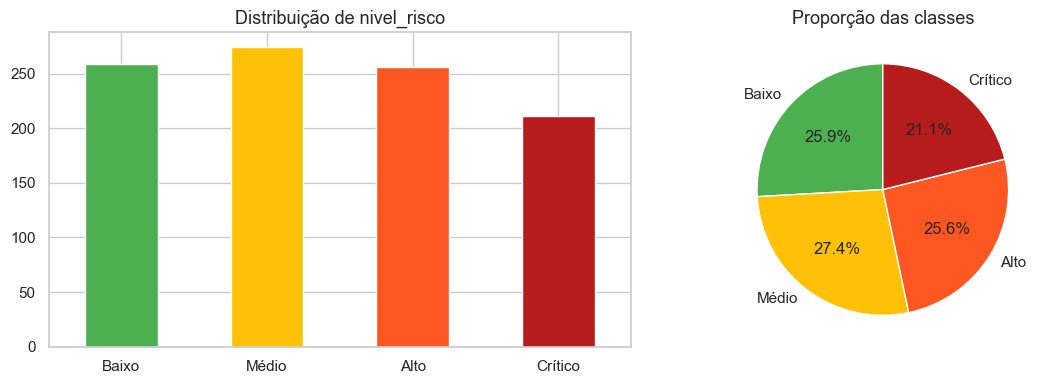

nivel_risco
Baixo      259
Médio      274
Alto       256
Crítico    211
Name: count, dtype: int64


In [15]:
target_col = 'nivel_risco'

# Se a coluna tiver nome diferente, ajuste aqui
if target_col not in df.columns:
    print('Colunas disponíveis:', df.columns.tolist())
else:
    counts = df[target_col].value_counts()
    ordem = ['Baixo', 'Médio', 'Alto', 'Crítico']
    counts = counts.reindex([c for c in ordem if c in counts.index])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    cores = ['#4CAF50', '#FFC107', '#FF5722', '#B71C1C']
    counts.plot(kind='bar', ax=ax1, color=cores[:len(counts)], edgecolor='white')
    ax1.set_title('Distribuição de nivel_risco')
    ax1.set_xlabel('')
    ax1.tick_params(axis='x', rotation=0)

    counts.plot(kind='pie', ax=ax2, colors=cores[:len(counts)], autopct='%1.1f%%', startangle=90)
    ax2.set_title('Proporção das classes')
    ax2.set_ylabel('')

    plt.tight_layout()
    plt.savefig('../../assets/eda_distribuicao_target.png', dpi=100, bbox_inches='tight')
    plt.show()
    print(counts)

## 4. Histogramas das features numéricas

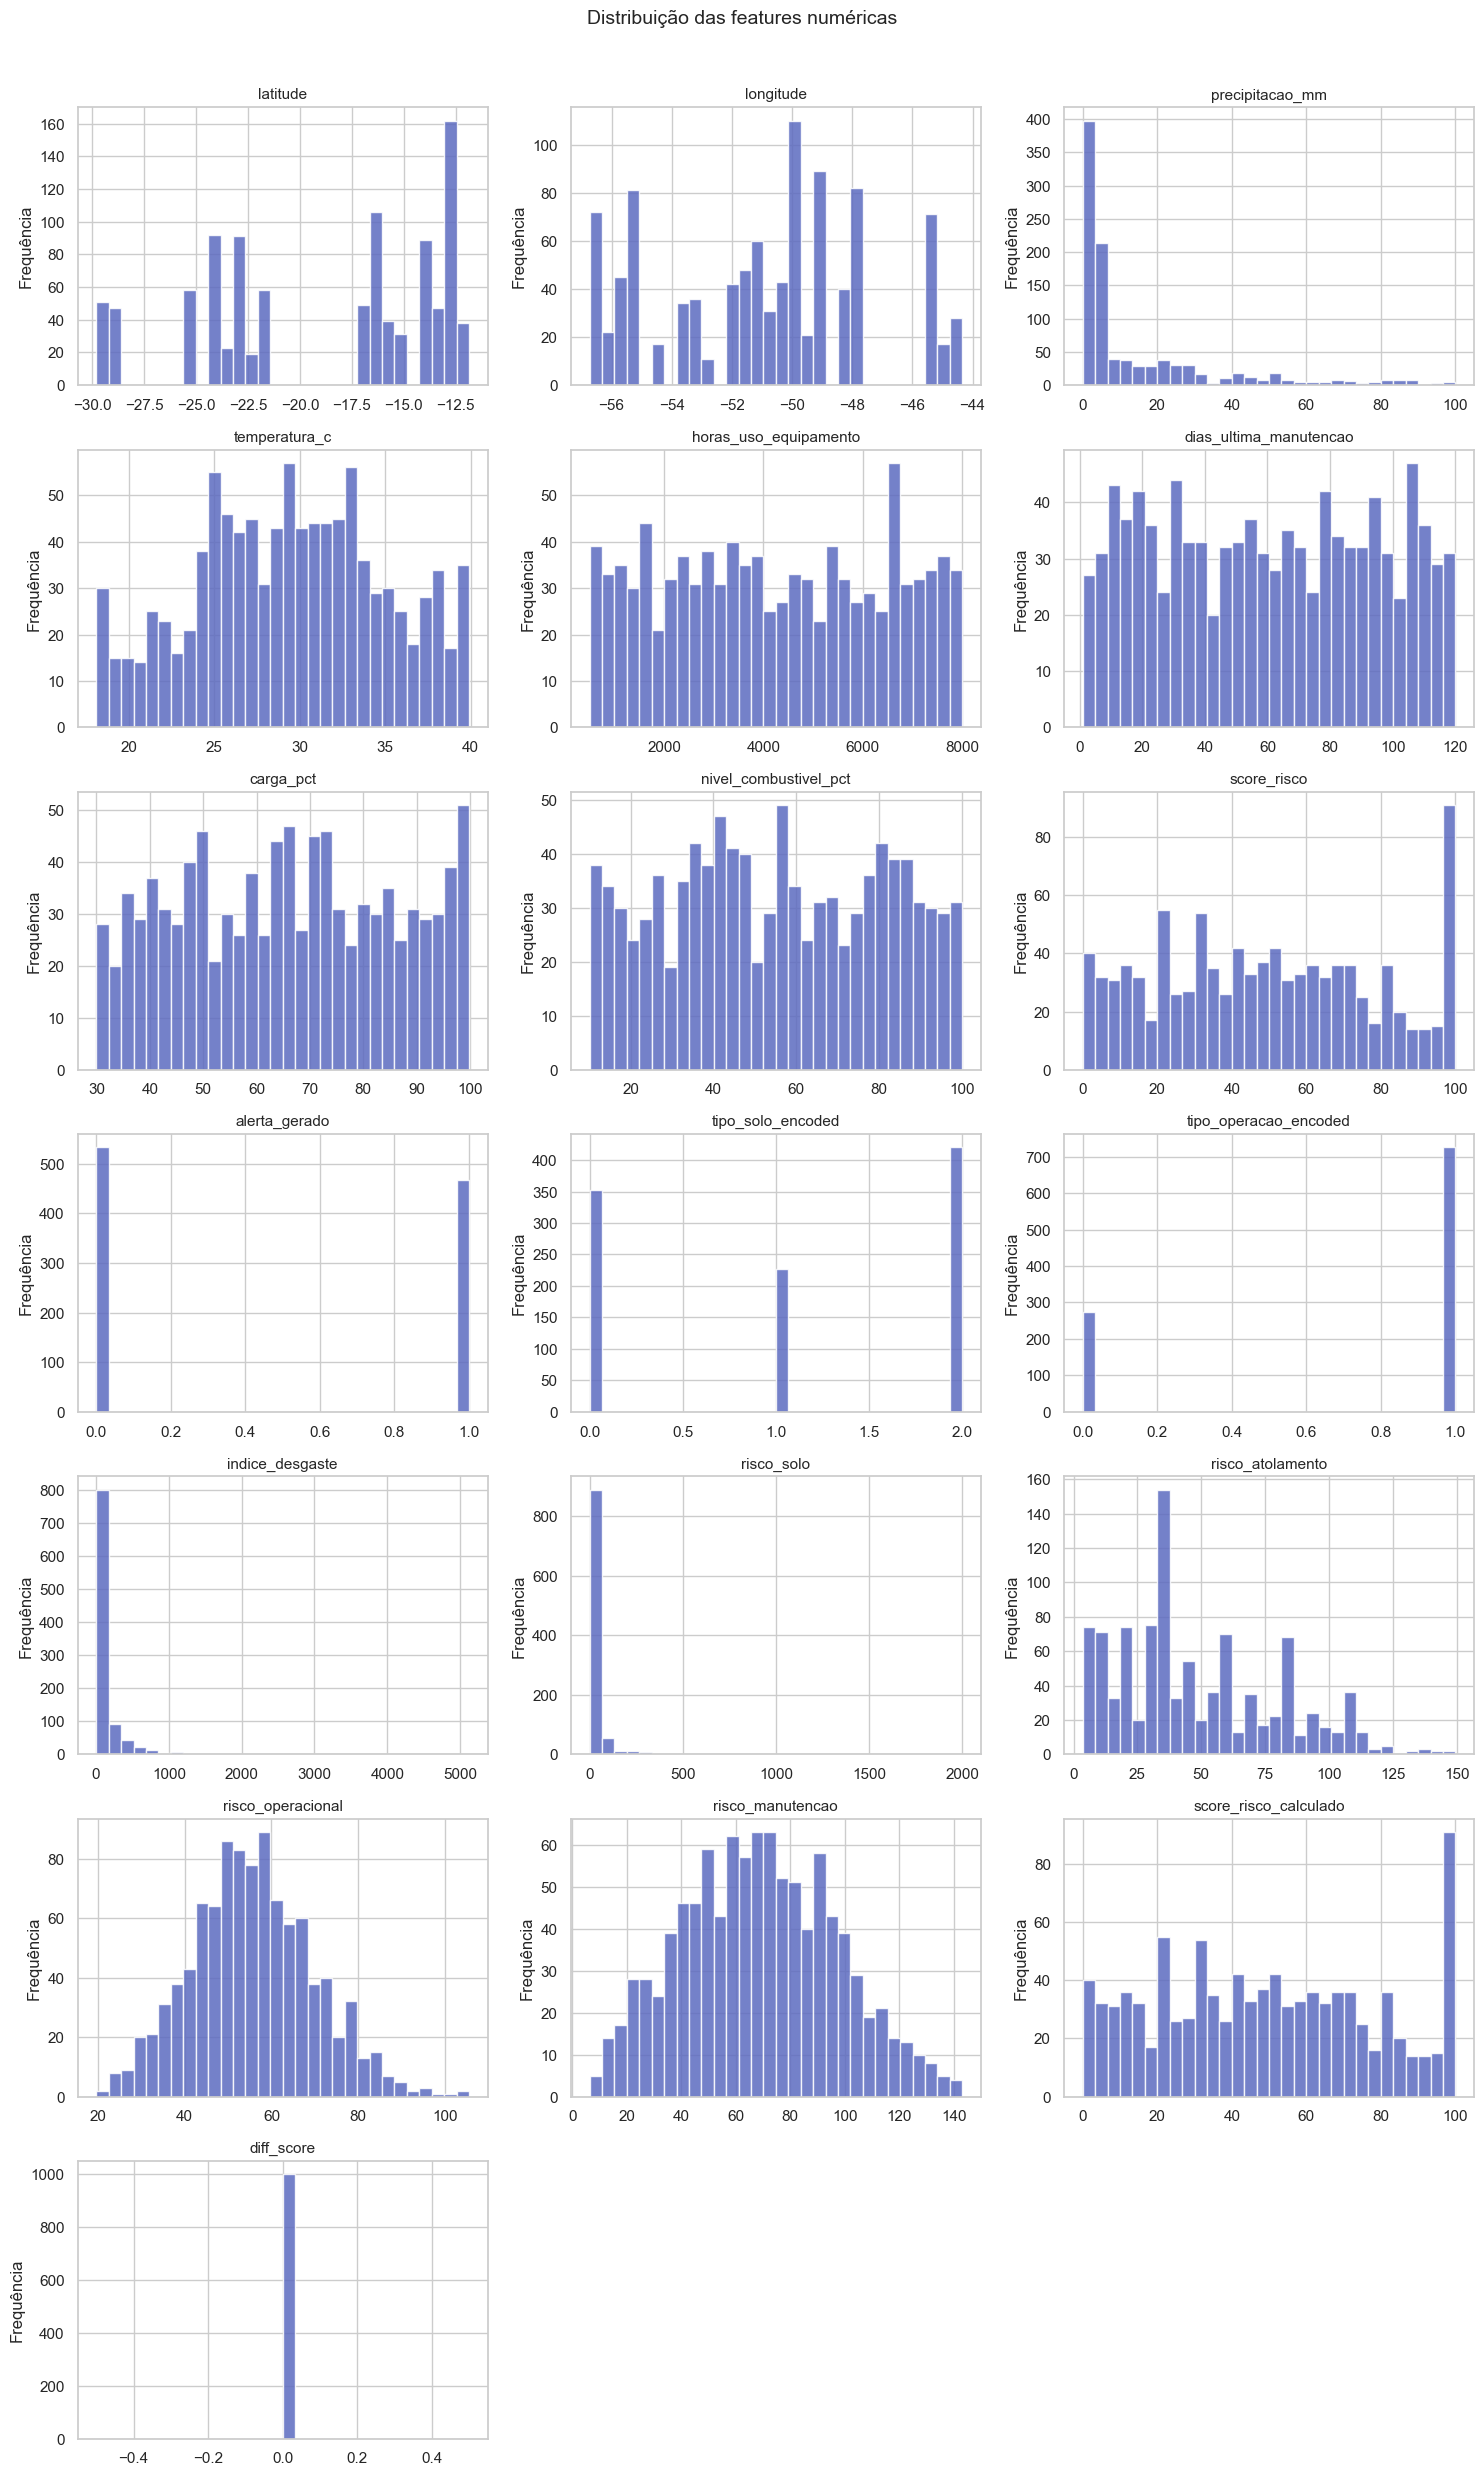

In [16]:
# Seleciona apenas colunas numéricas
numericas = df.select_dtypes(include='number').columns.tolist()
# Remove id e colunas codificadas (encoded) se quiser
numericas = [c for c in numericas if 'id' not in c.lower()]

n_cols = 3
n_rows = -(-len(numericas) // n_cols)  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(numericas):
    axes[i].hist(df[col].dropna(), bins=30, color='#5C6BC0', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Frequência')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuição das features numéricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../../assets/eda_histogramas.png', dpi=100, bbox_inches='tight')
plt.show()

## 5. Boxplots por nível de risco

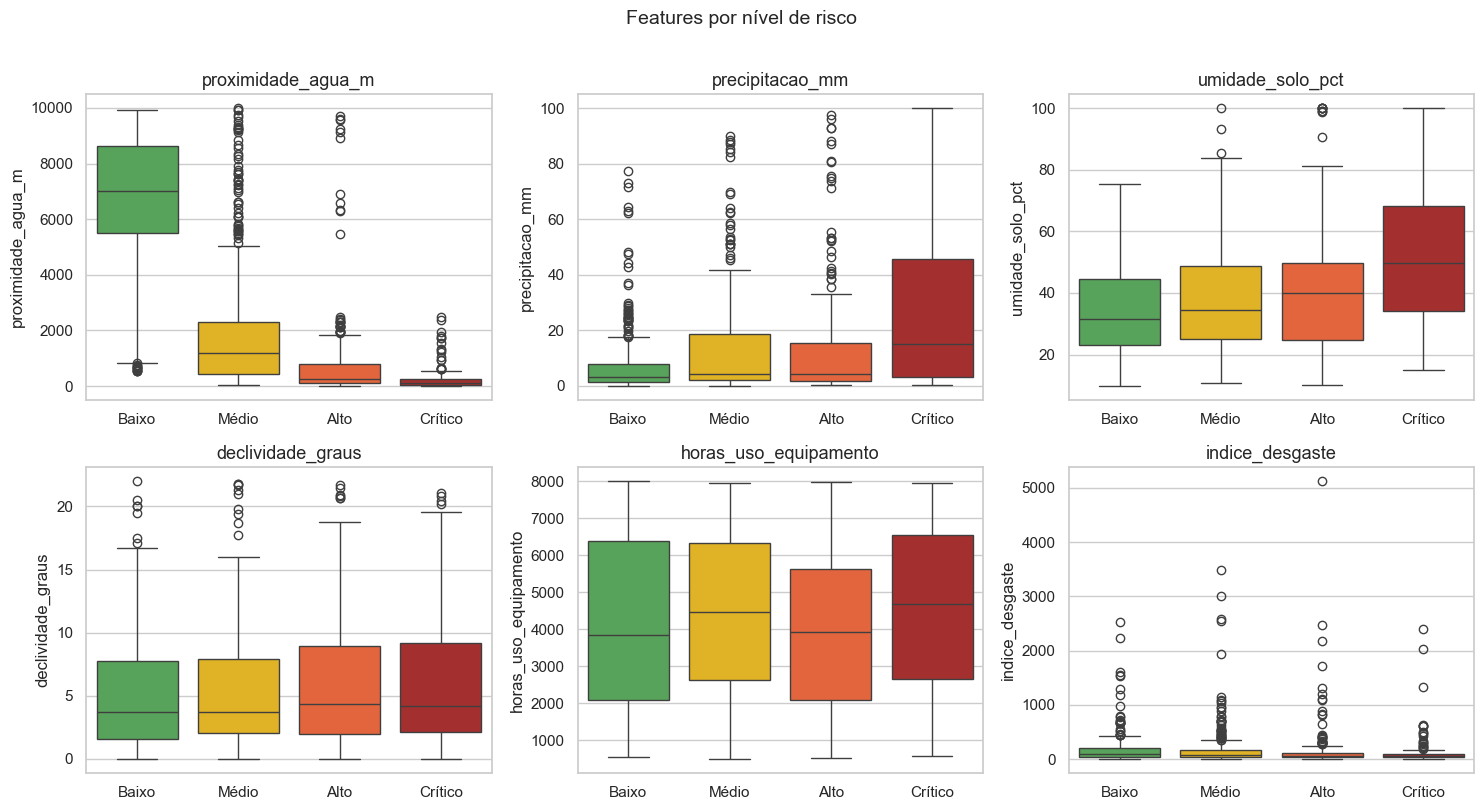

In [17]:
# Principais features para analisar contra o target
features_interesse = [
    'proximidade_agua_m', 'precipitacao_mm', 'umidade_solo_pct',
    'declividade_graus', 'horas_uso_equipamento', 'indice_desgaste'
]
features_interesse = [f for f in features_interesse if f in df.columns]

ordem = ['Baixo', 'Médio', 'Alto', 'Crítico']
ordem = [o for o in ordem if o in df[target_col].unique()]
cores = {'Baixo': '#4CAF50', 'Médio': '#FFC107', 'Alto': '#FF5722', 'Crítico': '#B71C1C'}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(features_interesse[:6]):
    sns.boxplot(
        data=df, x=target_col, y=feat, order=ordem,
        palette=cores, ax=axes[i]
    )
    axes[i].set_title(feat)
    axes[i].set_xlabel('')

plt.suptitle('Features por nível de risco', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../../assets/eda_boxplots.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. Heatmap de correlação

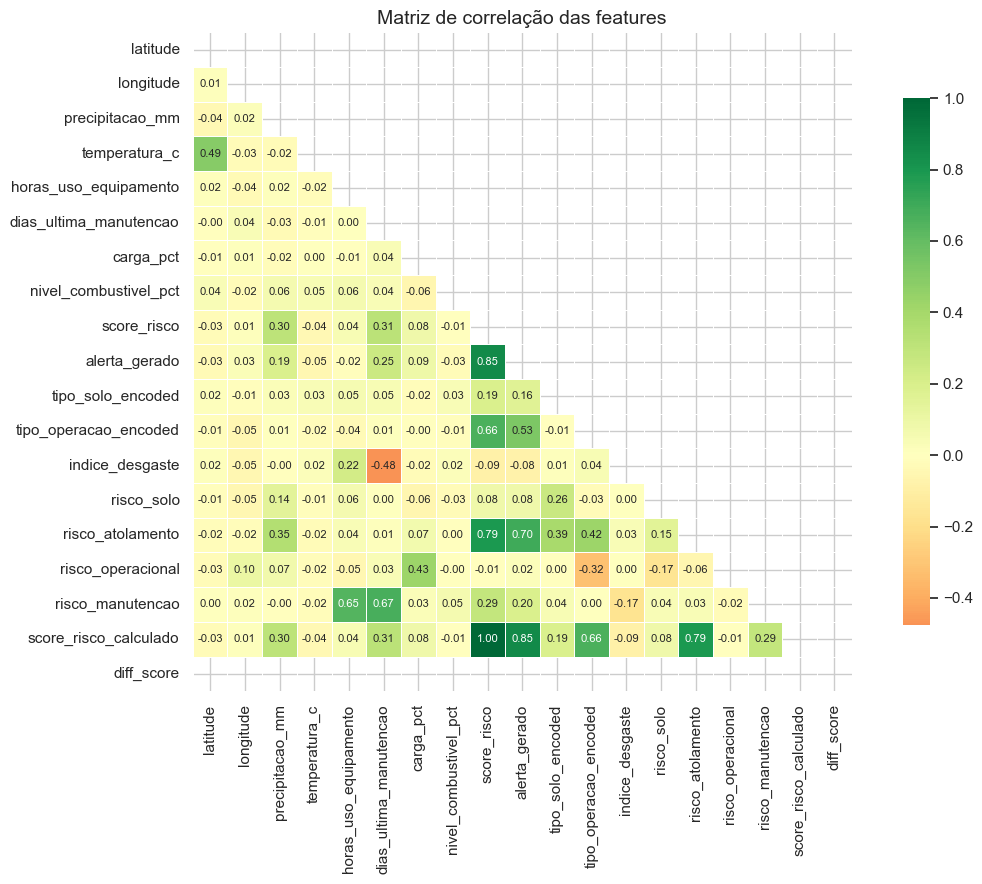

In [40]:
plt.figure(figsize=(12, 9))
corr = df[numericas].corr()

sns.heatmap(
    corr, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, square=True,
    linewidths=0.5, cbar_kws={'shrink': 0.8},
    annot_kws={'size': 7}
)
plt.title('Matriz de correlação das features', fontsize=14)
plt.tight_layout()
plt.savefig('../../assets/eda_correlacao.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. Identificação de outliers (IQR)

In [25]:
print('=== Outliers por feature (método IQR) ===')
for col in features_interesse:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
        print(f'  {col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)')

=== Outliers por feature (método IQR) ===
  proximidade_agua_m: 0 outliers (0.0%)
  precipitacao_mm: 94 outliers (9.4%)
  umidade_solo_pct: 35 outliers (3.5%)
  declividade_graus: 29 outliers (2.9%)
  horas_uso_equipamento: 0 outliers (0.0%)
  indice_desgaste: 128 outliers (12.8%)


## 8. Conclusões do EDA
- Anote aqui os principais achados antes de ir para a modelagem.
- Ex: 'proximidade_agua_m tem forte correlação negativa com nivel_risco'
- Ex: 'Classes estão balanceadas (≈25% cada)'